# 다중 비디오 프레임 추출

비디오는 여러 장의 이미지가 시간 순서대로 이어진 데이터이다. **프레임(frame)**은 그중 한 장이며, **FPS(Frames Per Second)**는 1초 동안 재생되는 프레임 수이다. 멀티모달 검색에서는 비디오 전체를 한 번에 비교하기보다 대표 프레임을 추출해 이미지 단위로 처리한다.

한 영상만 사용하면 검색할 장면의 종류가 제한된다. 이 실습에서는 강아지·요리·교통·사이클·농구·수영·서핑·달리기·축구의 Mixkit 영상 9개로 작은 **비디오 corpus**를 구성한다. corpus는 검색 대상으로 함께 관리하는 자료 모음이다.

각 영상의 시작과 끝은 타이틀이나 전환 화면일 수 있으므로 전체 길이의 5%부터 95%까지를 사용한다. 이 구간에서 영상마다 6개 프레임을 균등하게 선택해 총 54장의 검색 후보를 만든다.


## 전체 처리 흐름

각 영상의 출처와 다운로드 주소를 corpus 설정으로 관리하고, 실제 MP4의 메타데이터를 읽어 영상별 샘플 위치를 계산한다. JPEG와 두 manifest는 같은 corpus 폴더에 저장되어 다음 프레임 캡셔닝 노트북으로 전달된다.

```mermaid
flowchart TD
    A["Mixkit 영상 9개와 출처"] --> B["videos/에 MP4 저장"]
    B --> C["VideoCapture로 영상별 메타데이터 확인"]
    C --> D["video_manifest.jsonl 저장"]
    C --> E["영상별 5~95% 구간 계산"]
    E --> F["영상마다 6개 위치를 균등 선택"]
    F --> G["frames/{video_id}/에 JPEG 저장"]
    G --> H["총 54개 frame record 생성"]
    H --> I["frame_manifest.jsonl 저장"]
    G --> J["영상별 대표 프레임 3×3 확인"]
    I --> K["04 프레임 캡셔닝의 입력"]
```


## corpus 경로와 영상 출처 정의

`CORPUS_ID`는 이번 9개 영상 묶음을 다른 실험과 구분하는 이름이다. 영상마다 내부 식별자, 직접 다운로드 주소, 사람이 확인할 수 있는 공식 페이지와 라이선스 페이지를 함께 기록한다. 이후 생성되는 모든 산출물은 `artifacts/multimodal_rag/mixkit_9_v1` 아래에 모인다.


In [3]:
# %pip install opencv-python

  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl (44.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path
import hashlib
import json
import math

import cv2
import matplotlib.pyplot as plt
import requests
from IPython.display import Markdown, display

CORPUS_ID = 'mixkit_9_v1'
ARTIFACT_ROOT = Path('artifacts/multimodal_rag') / CORPUS_ID
VIDEO_DIR = ARTIFACT_ROOT / 'videos'
FRAME_ROOT = ARTIFACT_ROOT / 'frames'
VIDEO_MANIFEST_PATH = ARTIFACT_ROOT / 'video_manifest.jsonl'
FRAME_MANIFEST_PATH = ARTIFACT_ROOT / 'frame_manifest.jsonl'

MIXKIT_LICENSE_URL = 'https://mixkit.co/license/'

VIDEO_SOURCES = [
    {
        'video_id': 'dog_ball',
        'download_url': 'https://assets.mixkit.co/videos/42719/42719-720.mp4',
        'source_page': 'https://mixkit.co/free-stock-video/man-and-woman-playing-with-a-dog-in-a-garden-42719/',
        'license_url': MIXKIT_LICENSE_URL,
    },
    {
        'video_id': 'cooking',
        'download_url': 'https://assets.mixkit.co/videos/43063/43063-720.mp4',
        'source_page': 'https://mixkit.co/free-stock-video/frying-diced-bacon-in-a-skillet-43063/',
        'license_url': MIXKIT_LICENSE_URL,
    },
    {
        'video_id': 'traffic',
        'download_url': 'https://assets.mixkit.co/videos/4000/4000-720.mp4',
        'source_page': 'https://mixkit.co/free-stock-video/busy-street-in-the-city-4000/',
        'license_url': MIXKIT_LICENSE_URL,
    },
    {
        'video_id': 'cycling',
        'download_url': 'https://assets.mixkit.co/videos/194/194-720.mp4',
        'source_page': 'https://mixkit.co/free-stock-video/cyclist-riding-down-street-194/',
        'license_url': MIXKIT_LICENSE_URL,
    },
    {
        'video_id': 'basketball',
        'download_url': 'https://assets.mixkit.co/videos/2272/2272-720.mp4',
        'source_page': 'https://mixkit.co/free-stock-video/man-bouncing-a-basketball-ball-2272/',
        'license_url': MIXKIT_LICENSE_URL,
    },
    {
        'video_id': 'swimming',
        'download_url': 'https://assets.mixkit.co/videos/3170/3170-720.mp4',
        'source_page': 'https://mixkit.co/free-stock-video/swimmer-in-the-pool-seen-from-behind-3170/',
        'license_url': MIXKIT_LICENSE_URL,
    },
    {
        'video_id': 'surfing',
        'download_url': 'https://assets.mixkit.co/videos/1076/1076-720.mp4',
        'source_page': 'https://mixkit.co/free-stock-video/surfer-riding-the-waves-1076/',
        'license_url': MIXKIT_LICENSE_URL,
    },
    {
        'video_id': 'running',
        'download_url': 'https://assets.mixkit.co/videos/722/722-720.mp4',
        'source_page': 'https://mixkit.co/free-stock-video/runner-training-in-a-park-722/',
        'license_url': MIXKIT_LICENSE_URL,
    },
    {
        'video_id': 'soccer',
        'download_url': 'https://assets.mixkit.co/videos/4576/4576-720.mp4',
        'source_page': 'https://mixkit.co/free-stock-video/soccer-players-playing-on-a-field-4576/',
        'license_url': MIXKIT_LICENSE_URL,
    },
]

FRAME_SAMPLES_PER_VIDEO = 6
VIDEO_DIR.mkdir(parents=True, exist_ok=True)
FRAME_ROOT.mkdir(parents=True, exist_ok=True)

print(f'corpus_id={CORPUS_ID}')
print(f'video_sources={len(VIDEO_SOURCES)}')


corpus_id=mixkit_9_v1
video_sources=9


## 스트리밍 다운로드

`requests.get(..., stream=True)`는 응답 전체를 메모리에 올리지 않고 작은 chunk 단위로 파일에 기록한다. 다운로드 중에는 `.part` 임시 파일을 사용하고 모든 chunk 기록이 끝난 뒤 최종 `.mp4` 이름으로 바꾼다. 따라서 중간에 중단된 파일을 완성본으로 잘못 재사용하지 않는다.


In [5]:
def download_video(source: dict) -> Path:

    video_path = VIDEO_DIR / f"{source['video_id']}.mp4"
    part_path = video_path.with_suffix('.mp4.part')

    if video_path.is_file() and video_path.stat().st_size > 0:
        return video_path

    with requests.get(source['download_url'], stream=True, timeout=120) as response:
        response.raise_for_status()
        with part_path.open('wb') as file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    file.write(chunk)

    part_path.replace(video_path)
    return video_path

video_paths = {}
for source in VIDEO_SOURCES:
    video_path = download_video(source)
    video_paths[source['video_id']] = video_path
    print(f"{source['video_id']:>10} | {video_path.stat().st_size:>12,} bytes | {video_path}")


  dog_ball |    7,711,025 bytes | artifacts\multimodal_rag\mixkit_9_v1\videos\dog_ball.mp4
   cooking |    3,055,014 bytes | artifacts\multimodal_rag\mixkit_9_v1\videos\cooking.mp4
   traffic |    5,022,707 bytes | artifacts\multimodal_rag\mixkit_9_v1\videos\traffic.mp4
   cycling |    4,536,982 bytes | artifacts\multimodal_rag\mixkit_9_v1\videos\cycling.mp4
basketball |    6,705,420 bytes | artifacts\multimodal_rag\mixkit_9_v1\videos\basketball.mp4
  swimming |    4,138,183 bytes | artifacts\multimodal_rag\mixkit_9_v1\videos\swimming.mp4
   surfing |    5,561,610 bytes | artifacts\multimodal_rag\mixkit_9_v1\videos\surfing.mp4
   running |    8,835,318 bytes | artifacts\multimodal_rag\mixkit_9_v1\videos\running.mp4
    soccer |    4,453,097 bytes | artifacts\multimodal_rag\mixkit_9_v1\videos\soccer.mp4


## 영상 메타데이터와 video manifest

`VideoCapture`는 MP4를 열어 FPS, 전체 프레임 수와 해상도를 제공한다. 재생 시간은 `전체 프레임 수 ÷ FPS`로 계산한다. 각 영상의 출처 정보와 실제 파일 메타데이터를 하나의 record로 묶어 `video_manifest.jsonl`에 저장한다.


In [6]:
video_records = []
for source in VIDEO_SOURCES:
    video_path = video_paths[source['video_id']]
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        capture.release()
        raise ValueError(f'비디오를 열 수 없다: {video_path}')

    fps = float(capture.get(cv2.CAP_PROP_FPS))
    frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    capture.release()

    if not math.isfinite(fps) or fps <= 0 or frame_count <= 0:
        raise ValueError(f"유효하지 않은 영상 메타데이터이다: {source['video_id']}")

    video_records.append({
        'video_id': source['video_id'],
        'video_filename': video_path.name,
        'video_path': video_path.as_posix(),
        'source_page': source['source_page'],
        'download_url': source['download_url'],
        'license_url': source['license_url'],
        'fps': fps,
        'frame_count': frame_count,
        'duration_sec': frame_count / fps,
        'frame_width': frame_width,
        'frame_height': frame_height,
        'file_size_bytes': video_path.stat().st_size,
    })

with VIDEO_MANIFEST_PATH.open('w', encoding='utf-8') as file:
    for record in video_records:
        file.write(json.dumps(record, ensure_ascii=False) + '\n')

print(f'video_records={len(video_records)}')
print(f'video_manifest={VIDEO_MANIFEST_PATH}')


video_records=9
video_manifest=artifacts\multimodal_rag\mixkit_9_v1\video_manifest.jsonl


## 9개 영상 요약표

영상별 FPS, 프레임 수, 길이와 해상도를 한 표에서 비교한다. 길이가 달라도 다음 단계에서는 각 영상의 절대 초가 아니라 5~95%의 상대 구간을 사용하므로 장면을 균등하게 선택할 수 있다.


In [7]:
table_rows = [
    '| video_id | FPS | frames | duration(s) | resolution | source |',
    '|---|---:|---:|---:|---:|---|',
]
for record in video_records:

    frame_size = f"{record['frame_width']}×{record['frame_height']}"
    table_rows.append(
        f"| {record['video_id']} | {record['fps']:.2f} | {record['frame_count']} | "
        f"{record['duration_sec']:.2f} | {frame_size} | [Mixkit]({record['source_page']}) |"
    )

display(Markdown('\n'.join(table_rows)))


| video_id | FPS | frames | duration(s) | resolution | source |
|---|---:|---:|---:|---:|---|
| dog_ball | 23.98 | 498 | 20.77 | 1280×720 | [Mixkit](https://mixkit.co/free-stock-video/man-and-woman-playing-with-a-dog-in-a-garden-42719/) |
| cooking | 23.98 | 198 | 8.26 | 1280×720 | [Mixkit](https://mixkit.co/free-stock-video/frying-diced-bacon-in-a-skillet-43063/) |
| traffic | 30.00 | 401 | 13.37 | 1280×720 | [Mixkit](https://mixkit.co/free-stock-video/busy-street-in-the-city-4000/) |
| cycling | 23.98 | 313 | 13.05 | 1280×720 | [Mixkit](https://mixkit.co/free-stock-video/cyclist-riding-down-street-194/) |
| basketball | 24.00 | 546 | 22.75 | 1280×720 | [Mixkit](https://mixkit.co/free-stock-video/man-bouncing-a-basketball-ball-2272/) |
| swimming | 23.98 | 240 | 10.01 | 1280×720 | [Mixkit](https://mixkit.co/free-stock-video/swimmer-in-the-pool-seen-from-behind-3170/) |
| surfing | 23.98 | 434 | 18.10 | 1280×720 | [Mixkit](https://mixkit.co/free-stock-video/surfer-riding-the-waves-1076/) |
| running | 23.98 | 720 | 30.03 | 1280×720 | [Mixkit](https://mixkit.co/free-stock-video/runner-training-in-a-park-722/) |
| soccer | 30.00 | 392 | 13.07 | 1280×720 | [Mixkit](https://mixkit.co/free-stock-video/soccer-players-playing-on-a-field-4576/) |

## 영상별 5~95% 프레임 추출

첫 위치는 `(전체 프레임 수-1)×0.05`, 마지막 위치는 `(전체 프레임 수-1)×0.95`로 계산한다. 두 위치를 포함해 6개 지점을 같은 간격으로 나누면 시작·끝 전환을 피하면서 영상 중간의 흐름을 고르게 포함할 수 있다.

프레임 ID는 `video_id:frame_no`의 SHA-256 앞 16자리로 만든다. 같은 corpus를 다시 실행하면 같은 프레임이 같은 ID를 얻으므로 이후 캡션과 검색 결과를 안정적으로 연결할 수 있다.


In [8]:
def select_frame_numbers(frame_count: int, sample_count: int) -> list[int]:
    # 마지막 유효 인덱스를 기준으로 5%와 95% 위치를 정수 프레임 번호로 변환한다.
    first_frame = round((frame_count - 1) * 0.05)
    last_frame = round((frame_count - 1) * 0.95)
    span = last_frame - first_frame

    # i=0~5를 구간 양 끝에 포함해 균등 배치하고 실제 접근 가능한 정수 번호로 반올림한다.
    frame_numbers = [
        round(first_frame + span * index / (sample_count - 1))
        for index in range(sample_count)
    ]
    if len(set(frame_numbers)) != sample_count:
        raise ValueError(f'고유 프레임 {sample_count}개를 선택할 수 없다: {frame_count=}')
    return frame_numbers

frame_records = []
for video_record in video_records:
    video_id = video_record['video_id']
    video_frame_dir = FRAME_ROOT / video_id
    video_frame_dir.mkdir(parents=True, exist_ok=True)
    frame_numbers = select_frame_numbers(video_record['frame_count'], FRAME_SAMPLES_PER_VIDEO)

    capture = cv2.VideoCapture(video_record['video_path'])
    if not capture.isOpened():
        capture.release()
        raise ValueError(f"비디오를 열 수 없다: {video_record['video_path']}")

    for frame_no in frame_numbers:
        # 디코더를 선택 위치로 이동한 뒤 BGR 픽셀 배열 한 장을 읽는다.
        capture.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
        success, frame_bgr = capture.read()
        if not success or frame_bgr is None:
            capture.release()
            raise RuntimeError(f'프레임을 읽을 수 없다: {video_id}:{frame_no}')

        frame_path = video_frame_dir / f'{video_id}_frame{frame_no:07d}.jpg'
        if not cv2.imwrite(str(frame_path), frame_bgr):
            capture.release()
            raise OSError(f'프레임 저장에 실패했다: {frame_path}')

        # video_id와 frame_no를 함께 hash해 다른 영상의 같은 프레임 번호와 ID가 겹치지 않게 한다.
        raw_frame_id = f'{video_id}:{frame_no}'.encode('utf-8')
        frame_records.append({
            'frame_id': hashlib.sha256(raw_frame_id).hexdigest()[:16],
            'video_id': video_id,
            'video_filename': video_record['video_filename'],
            'video_path': video_record['video_path'],
            'frame_path': frame_path.as_posix(),
            'frame_no': frame_no,
            'timestamp_sec': frame_no / video_record['fps'],
            'source_page': video_record['source_page'],
        })
    capture.release()

expected_frame_count = len(VIDEO_SOURCES) * FRAME_SAMPLES_PER_VIDEO
if len(frame_records) != expected_frame_count:
    raise ValueError(f'저장 프레임 수가 예상과 다르다: {len(frame_records)} != {expected_frame_count}')

# 프레임 하나를 JSON 한 줄로 기록해 04 캡셔닝 단계가 이미지와 영상 metadata를 함께 읽게 한다.
with FRAME_MANIFEST_PATH.open('w', encoding='utf-8') as file:
    for record in frame_records:
        file.write(json.dumps(record, ensure_ascii=False) + '\n')

print(f'saved_frames={len(frame_records)}')
print(f'frame_manifest={FRAME_MANIFEST_PATH}')

saved_frames=54
frame_manifest=artifacts\multimodal_rag\mixkit_9_v1\frame_manifest.jsonl


## 영상별 대표 프레임 contact sheet

각 영상의 첫 번째 샘플 프레임을 하나씩 선택해 3×3으로 표시한다. OpenCV가 읽은 BGR 배열은 `matplotlib`에 맞게 RGB로 변환한다. 서로 다른 9개 주제가 한눈에 구분되면 다음 캡셔닝과 검색 실습에 사용할 corpus가 올바르게 구성된 것이다.


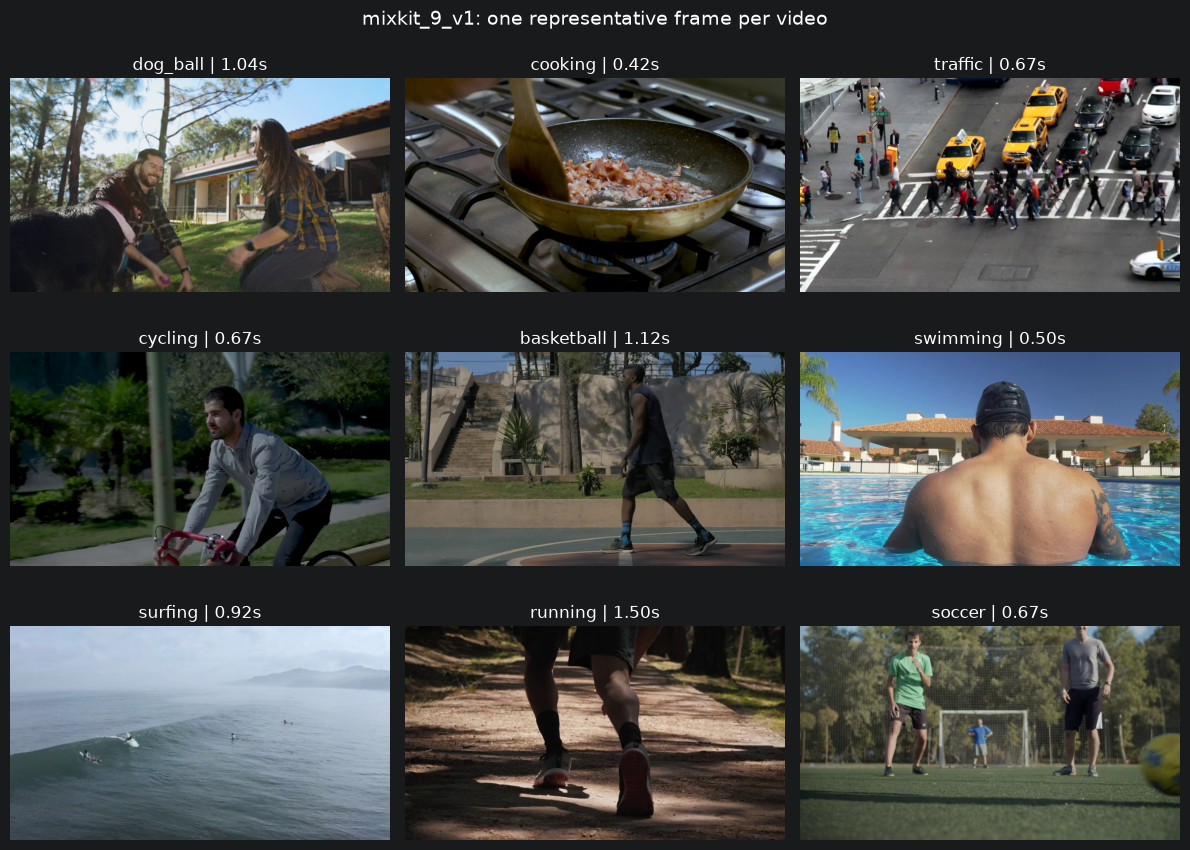

In [9]:
representative_records = [
    next(record for record in frame_records if record['video_id'] == source['video_id'])
    for source in VIDEO_SOURCES
]

figure, axes = plt.subplots(3, 3, figsize=(12, 9))
for axis, record in zip(axes.ravel(), representative_records):
    frame_bgr = cv2.imread(record['frame_path'])
    if frame_bgr is None:
        raise FileNotFoundError(f"프레임 이미지를 읽을 수 없다: {record['frame_path']}")

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    axis.imshow(frame_rgb)
    axis.set_title(f"{record['video_id']} | {record['timestamp_sec']:.2f}s")
    axis.axis('off')

figure.suptitle(f'{CORPUS_ID}: one representative frame per video', fontsize=14)
figure.tight_layout()
plt.show()
